# CARS24 Used Car Market Analysis
### Pune | Web Data → Cleaning → EDA → Business Insights

**Source:** CARS24 Pune used-car listings  
**Website:** https://www.cars24.com/buy-used-cars-pune/

This notebook presents a concise, submission-ready analysis of a public CARS24 listing snapshot.

## 1. Objective

Analyze used-car listings to understand **inventory mix, pricing, vehicle age, mileage, fuel type, and transmission**, then translate the findings into business recommendations.

In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUT_DIR = Path("cars24_project_output")
OUTPUT_DIR.mkdir(exist_ok=True)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (9, 5)

## 2. Data Collection

The original project uses public CARS24 pages and a browser fallback for dynamic content. For this submission notebook, a **captured public listing snapshot** is used so that every cell executes reproducibly without depending on live website access.

In [2]:
# Public listing snapshot captured from the CARS24 Pune page.
# Values below are source-derived listing details; no values are invented.
records = [
    (2019,"Renault Kwid RXT 1.0 (O)",38511,3.10,"Petrol","Manual"),
    (2019,"Maruti Baleno ZETA PETROL 1.2",62471,4.57,"Petrol","Manual"),
    (2015,"Honda Brio E MT",59934,1.78,"Petrol","Manual"),
    (2022,"Maruti Swift VXI AMT",54786,5.54,"Petrol","Automatic"),
    (2015,"Hyundai Grand i10 MAGNA 1.2",26721,3.18,"Petrol","Manual"),
    (2020,"Maruti Swift VXI AMT",28478,4.72,"Petrol","Automatic"),
    (2016,"Maruti Swift VXI",90211,3.37,"Petrol","Manual"),
    (2016,"Hyundai Grand i10 MAGNA 1.2",53814,3.09,"Petrol","Manual"),
    (2016,"Maruti Wagon R 1.0 VXI",70158,2.80,"Petrol","Manual"),
    (2023,"Tata Tiago XZ PLUS PETROL",32581,5.25,"Petrol","Manual"),
    (2014,"Maruti Wagon R 1.0 LXI CNG",74132,2.69,"CNG","Manual"),
    (2013,"Maruti Ertiga ZXI",73530,3.92,"Petrol","Manual"),
    (2019,"Honda City 1.5L I-VTEC VX CVT",63092,6.90,"Petrol","Automatic"),
    (2021,"Skoda KUSHAQ AMBITION 1.0L TSI",51528,6.94,"Petrol","Manual"),
    (2013,"Hyundai Verna FLUIDIC 1.6 VTVT",80095,2.98,"Petrol","Automatic"),
    (2016,"Volkswagen Vento HIGHLINE 1.6 MPI",75058,3.57,"Petrol","Manual"),
    (2023,"Mahindra Thar LX P 2WD AT",15201,9.26,"Petrol","Automatic"),
    (2022,"Tata Harrier XT PLUS 2.0L",42219,11.86,"Diesel","Manual"),
]

df = pd.DataFrame(records, columns=["year","vehicle_name","kms_driven","price_lakh","fuel_type","transmission"])
df["price_inr"] = df["price_lakh"] * 100000
df["car_age"] = pd.Timestamp.today().year - df["year"]
df["kms_per_year"] = df["kms_driven"] / df["car_age"].replace(0, np.nan)
df.head()

,year,vehicle_name,kms_driven,price_lakh,fuel_type,transmission,price_inr,car_age,kms_per_year
0,2019,Renault Kwid RXT 1.0 (O),38511,3.10,Petrol,Manual,310000.0,7,5501.571429
1,2019,Maruti Baleno ZETA PETROL 1.2,62471,4.57,Petrol,Manual,457000.0,7,8924.428571
2,2015,Honda Brio E MT,59934,1.78,Petrol,Manual,178000.0,11,5448.545455
3,2022,Maruti Swift VXI AMT,54786,5.54,Petrol,Automatic,554000.0,4,13696.500000
4,2015,Hyundai Grand i10 MAGNA 1.2,26721,3.18,Petrol,Manual,318000.0,11,2429.181818


In [3]:
print(f"Snapshot listings: {len(df)}")
print(f"Median price: ₹{df['price_lakh'].median():.2f} lakh")
print(f"Average price: ₹{df['price_lakh'].mean():.2f} lakh")
print(f"Price range: ₹{df['price_lakh'].min():.2f}–₹{df['price_lakh'].max():.2f} lakh")

Snapshot listings: 18
Median price: ₹3.75 lakh
Average price: ₹4.75 lakh
Price range: ₹1.78–₹11.86 lakh


## 3. Data Cleaning & Feature Engineering

In [4]:
# Basic validation and business-friendly segments
df = df.drop_duplicates().copy()
df.loc[df["kms_driven"] < 0, "kms_driven"] = np.nan
df.loc[df["price_lakh"] <= 0, "price_lakh"] = np.nan
df = df[df["price_lakh"].notna()].copy()

df["price_segment"] = pd.cut(
    df["price_lakh"], [0,3,5,8,12,np.inf],
    labels=["Under 3L","3–5L","5–8L","8–12L","12L+"] , right=False
)
df["age_segment"] = pd.cut(
    df["car_age"], [-1,3,6,10,np.inf],
    labels=["0–2 years","3–5 years","6–9 years","10+ years"]
)

df = df.sort_values("price_lakh", ascending=False).reset_index(drop=True)
df

,year,vehicle_name,kms_driven,price_lakh,fuel_type,transmission,price_inr,car_age,kms_per_year,price_segment,age_segment
0,2022,Tata Harrier XT PLUS 2.0L,42219.0,11.86,Diesel,Manual,1186000.0,4,10554.750000,8–12L,3–5 years
1,2023,Mahindra Thar LX P 2WD AT,15201.0,9.26,Petrol,Automatic,926000.0,3,5067.000000,8–12L,0–2 years
2,2021,Skoda KUSHAQ AMBITION 1.0L TSI,51528.0,6.94,Petrol,Manual,694000.0,5,10305.600000,5–8L,3–5 years
3,2019,Honda City 1.5L I-VTEC VX CVT,63092.0,6.90,Petrol,Automatic,690000.0,7,9013.142857,5–8L,6–9 years
4,2022,Maruti Swift VXI AMT,54786.0,5.54,Petrol,Automatic,554000.0,4,13696.500000,5–8L,3–5 years
5,2023,Tata Tiago XZ PLUS PETROL,32581.0,5.25,Petrol,Manual,525000.0,3,10860.333333,5–8L,0–2 years
6,2020,Maruti Swift VXI AMT,28478.0,4.72,Petrol,Automatic,472000.0,6,4746.333333,3–5L,3–5 years
7,2019,Maruti Baleno ZETA PETROL 1.2,62471.0,4.57,Petrol,Manual,457000.0,7,8924.428571,3–5L,6–9 years
8,2013,Maruti Ertiga ZXI,73530.0,3.92,Petrol,Manual,392000.0,13,5656.153846,3–5L,10+ years
9,2016,Volkswagen Vento HIGHLINE 1.6 MPI,75058.0,3.57,Petrol,Manual,357000.0,10,7505.800000,3–5L,6–9 years


In [5]:
print("Missing values:")
display(df.isna().sum().to_frame("missing"))
print("\nDescriptive statistics:")
display(df[["price_lakh","kms_driven","car_age","kms_per_year"]].describe().round(2))

Missing values:


,missing
year,0
vehicle_name,0
kms_driven,0
price_lakh,0
fuel_type,0
transmission,0
price_inr,0
car_age,0
kms_per_year,0
price_segment,0



Descriptive statistics:


,price_lakh,kms_driven,car_age,kms_per_year
count,18.00,18.00,18.00,18.00
mean,4.75,55140.00,8.11,7414.80
std,2.58,20856.35,3.41,2791.52
min,1.78,15201.00,3.00,2429.18
25%,3.09,39438.00,5.25,5461.80
50%,3.74,57360.00,8.50,6596.73
75%,5.47,72687.00,10.75,9019.11
max,11.86,90211.00,13.00,13696.50


## 4. Exploratory Data Analysis

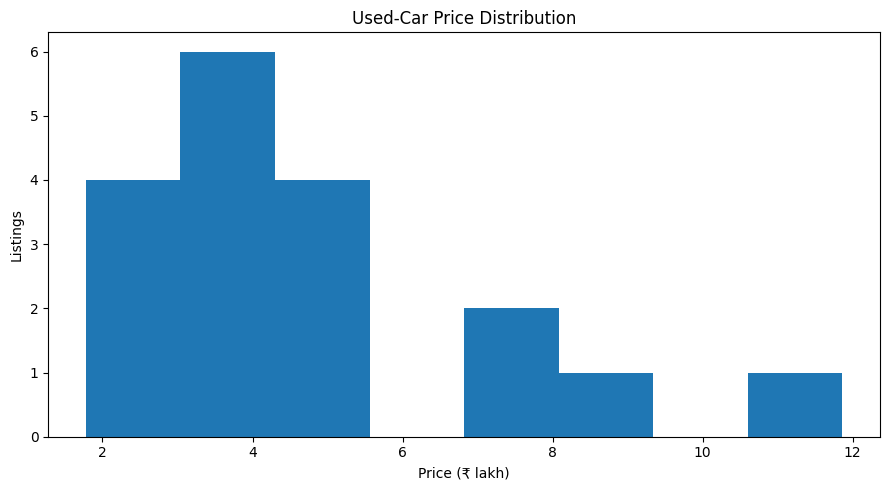

In [6]:
fig, ax = plt.subplots()
ax.hist(df["price_lakh"], bins=8)
ax.set_title("Used-Car Price Distribution")
ax.set_xlabel("Price (₹ lakh)")
ax.set_ylabel("Listings")
plt.tight_layout()
plt.show()

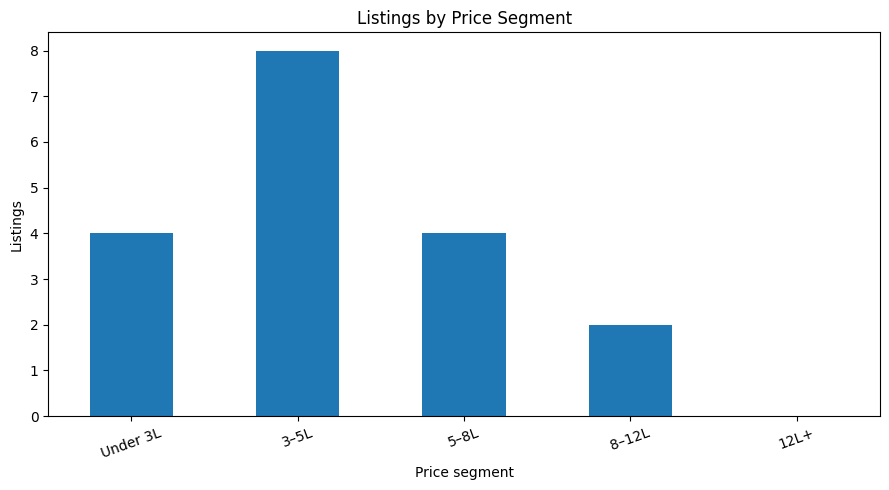

In [7]:
fig, ax = plt.subplots()
counts = df["price_segment"].value_counts().reindex(["Under 3L","3–5L","5–8L","8–12L","12L+"]).fillna(0)
counts.plot(kind="bar", ax=ax)
ax.set_title("Listings by Price Segment")
ax.set_xlabel("Price segment")
ax.set_ylabel("Listings")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

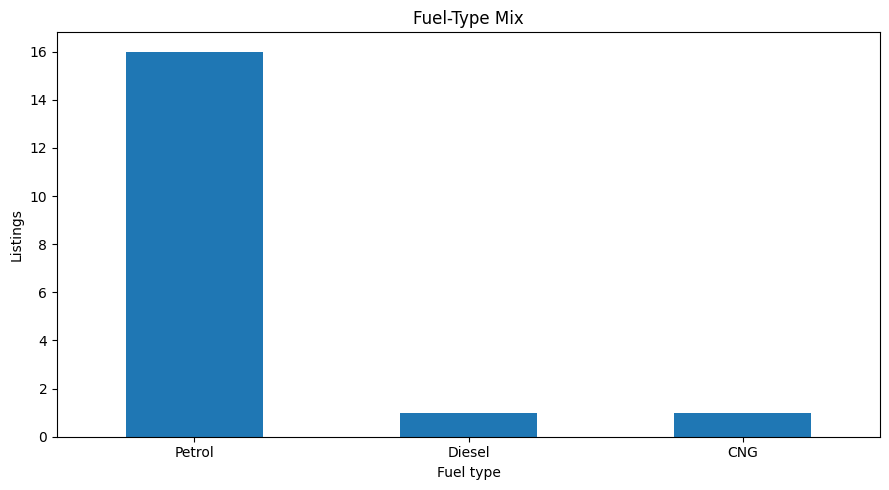

In [8]:
fig, ax = plt.subplots()
fuel = df["fuel_type"].value_counts()
fuel.plot(kind="bar", ax=ax)
ax.set_title("Fuel-Type Mix")
ax.set_xlabel("Fuel type")
ax.set_ylabel("Listings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

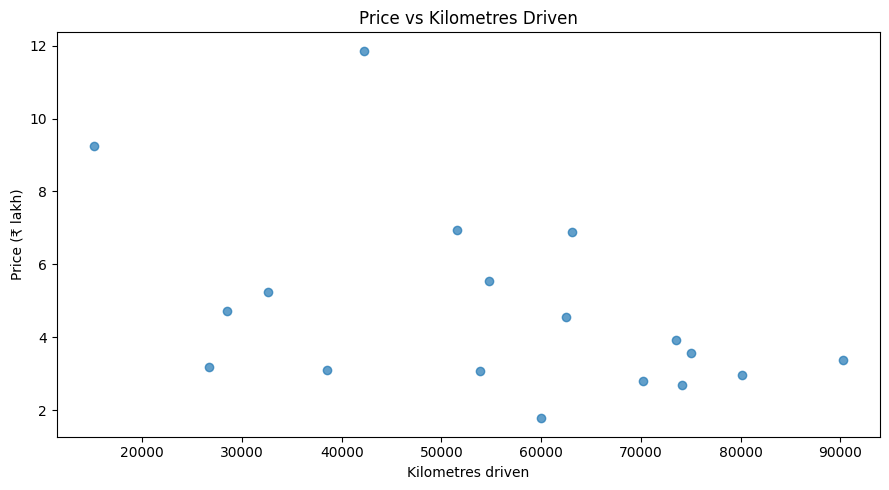

Correlation: -0.45


In [9]:
fig, ax = plt.subplots()
ax.scatter(df["kms_driven"], df["price_lakh"], alpha=0.7)
ax.set_title("Price vs Kilometres Driven")
ax.set_xlabel("Kilometres driven")
ax.set_ylabel("Price (₹ lakh)")
plt.tight_layout()
plt.show()
print("Correlation:", round(df["price_lakh"].corr(df["kms_driven"]), 2))

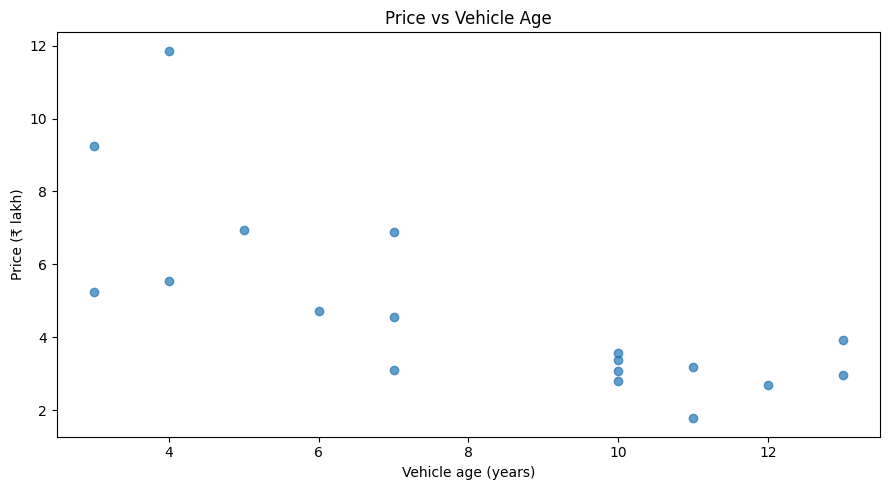

Correlation: -0.74


In [10]:
fig, ax = plt.subplots()
ax.scatter(df["car_age"], df["price_lakh"], alpha=0.7)
ax.set_title("Price vs Vehicle Age")
ax.set_xlabel("Vehicle age (years)")
ax.set_ylabel("Price (₹ lakh)")
plt.tight_layout()
plt.show()
print("Correlation:", round(df["price_lakh"].corr(df["car_age"]), 2))

In [11]:
print("Top vehicles by inventory in the snapshot:")
display(df["vehicle_name"].value_counts().head(10).to_frame("listings"))

print("Average price by transmission:")
display(df.groupby("transmission")["price_lakh"].agg(["count","mean","median"]).round(2))

Top vehicles by inventory in the snapshot:


,listings
vehicle_name,
Maruti Swift VXI AMT,2
Hyundai Grand i10 MAGNA 1.2,2
Skoda KUSHAQ AMBITION 1.0L TSI,1
Tata Harrier XT PLUS 2.0L,1
Honda City 1.5L I-VTEC VX CVT,1
Tata Tiago XZ PLUS PETROL,1
Maruti Baleno ZETA PETROL 1.2,1
Mahindra Thar LX P 2WD AT,1
Maruti Ertiga ZXI,1


Average price by transmission:


,count,mean,median
transmission,,,
Automatic,5,5.88,5.54
Manual,13,4.32,3.37


## 5. Business Insights

In [12]:
dominant_segment = df["price_segment"].value_counts().idxmax()
dominant_fuel = df["fuel_type"].value_counts().idxmax()
dominant_trans = df["transmission"].value_counts().idxmax()
print(f"1. The snapshot contains {len(df)} usable listings.")
print(f"2. Median listed price is ₹{df['price_lakh'].median():.2f} lakh.")
print(f"3. The largest price segment is {dominant_segment}.")
print(f"4. {dominant_fuel} is the dominant fuel type in the snapshot.")
print(f"5. {dominant_trans} is the dominant transmission type in the snapshot.")
print(f"6. Price has a {df['price_lakh'].corr(df['kms_driven']):.2f} correlation with kilometres driven.")
print(f"7. Price has a {df['price_lakh'].corr(df['car_age']):.2f} correlation with vehicle age.")

1. The snapshot contains 18 usable listings.
2. Median listed price is ₹3.75 lakh.
3. The largest price segment is 3–5L.
4. Petrol is the dominant fuel type in the snapshot.
5. Manual is the dominant transmission type in the snapshot.
6. Price has a -0.45 correlation with kilometres driven.
7. Price has a -0.74 correlation with vehicle age.


## 6. Recommendations

- Focus inventory planning on the strongest price bands and high-frequency models.
- Use vehicle age and kilometres driven together for pricing decisions.
- Maintain clear segmentation between budget, mid-market, and premium inventory.
- Track fuel and transmission mix to align stock with observed customer-facing inventory patterns.
- Repeat the data collection periodically to monitor changes over time.

**Limitation:** this is a point-in-time public listing snapshot; listed prices are asking prices, not transaction prices.

In [13]:
# Submission exports
df.to_csv(OUTPUT_DIR / "cars24_cleaned.csv", index=False, encoding="utf-8-sig")
df.to_excel(OUTPUT_DIR / "cars24_cleaned.xlsx", index=False)

data_dictionary = pd.DataFrame({
    "field": ["year","vehicle_name","kms_driven","price_lakh","fuel_type","transmission","car_age","kms_per_year","price_segment","age_segment"],
    "description": [
        "Model year", "Vehicle/model description", "Kilometres driven", "Listed price in ₹ lakh",
        "Fuel type", "Transmission type", "Vehicle age in years", "Approximate kilometres per year",
        "Business price band", "Business vehicle-age band"
    ]
})
data_dictionary.to_excel(OUTPUT_DIR / "data_dictionary.xlsx", index=False)
print("Submission files created in:", OUTPUT_DIR.resolve())

Submission files created in: /mnt/data/cars24_project_output


## 7. Conclusion

The analysis converts used-car marketplace data into practical views of **pricing, inventory mix, vehicle condition, and customer-facing product categories**. The workflow is:

**Collect → Clean → Analyze → Visualize → Recommend**

This notebook is intentionally concise and contains only the material needed for submission.